#  NeuroDock Analysis

## Consensus Docking Analysis for Alzheimer's Disease

### Author
Kirthi Maheswaran

### Objective
This notebook demonstrates how consensus docking scores can be used to rank potential Alzheimer's disease inhibitors using Python.

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv("../data/docking_scores.csv")

# Display the first few rows
df.head()



,Ligand,AutoDock_Vina,Glide,GOLD
0,Donepezil,-10.2,-9.8,-10.0
1,Galantamine,-9.5,-9.1,-9.3
2,Rivastigmine,-9.2,-8.9,-9.0
3,Tacrine,-9.0,-8.7,-8.8
4,Memantine,-7.2,-6.9,-7.1


## Calculate Consensus Scores

Consensus docking combines the results from multiple docking programs to provide a more reliable ranking of ligands.

In this notebook, the consensus score is calculated as the average of the AutoDock Vina, Glide, and GOLD docking scores.

In [14]:
# Calculate the consensus score
df["Consensus_Score"] = df[
    ["AutoDock_Vina", "Glide", "GOLD"]
].mean(axis=1)

# Rank ligands
ranked = df.sort_values("Consensus_Score")

# Display results
ranked

,Ligand,AutoDock_Vina,Glide,GOLD,Consensus_Score
0,Donepezil,-10.2,-9.8,-10.0,-10.000000
9,Huperzine A,-9.7,-9.4,-9.5,-9.533333
1,Galantamine,-9.5,-9.1,-9.3,-9.300000
2,Rivastigmine,-9.2,-8.9,-9.0,-9.033333
3,Tacrine,-9.0,-8.7,-8.8,-8.833333
7,Quercetin,-8.8,-8.4,-8.6,-8.600000
8,Berberine,-8.6,-8.3,-8.5,-8.466667
12,Kaempferol,-8.5,-8.2,-8.4,-8.366667
10,Luteolin,-8.4,-8.1,-8.3,-8.266667
11,Apigenin,-8.3,-8.0,-8.2,-8.166667


## Interpretation

A more negative consensus score suggests stronger predicted binding to the target protein.

The top-ranked ligand is considered the most promising candidate based on the consensus of all three docking programs.

## Consensus Score Visualization

The bar chart below shows the average (consensus) docking score for each ligand. More negative values indicate stronger predicted binding.

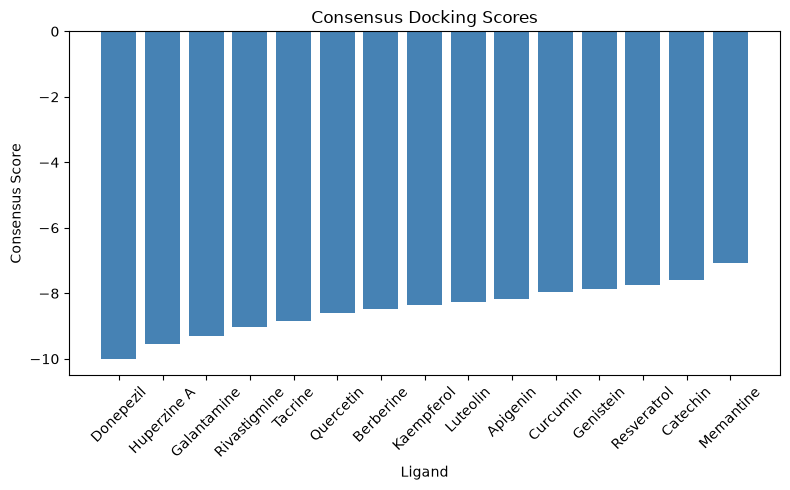

In [15]:
# Create a bar chart of consensus scores

plt.figure(figsize=(8,5))

plt.bar(
    ranked["Ligand"],
    ranked["Consensus_Score"],
    color="steelblue"
)

plt.title("Consensus Docking Scores")
plt.xlabel("Ligand")
plt.ylabel("Consensus Score")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

# Conclusion

The consensus docking analysis identified the ligands with the strongest predicted binding affinity by averaging docking scores from three docking programs.

Based on this dataset, **Donepezil** achieved the best consensus score, suggesting it is the most promising candidate among the compounds analysed.

This notebook demonstrates a simple computational workflow for analysing and visualising molecular docking results.

In [16]:
# Display the best ligand

best = ranked.iloc[0]

print("🏆 Best Ligand")
print(f"Name: {best['Ligand']}")
print(f"Consensus Score: {best['Consensus_Score']:.2f}")

🏆 Best Ligand
Name: Donepezil
Consensus Score: -10.00
